# Heat Equation with PINNs

This notebook demonstrates how to solve the **1D heat equation** using Physics-Informed Neural Networks (PINNs).

## The Problem

We solve the heat diffusion equation:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

with:
- **Domain**: $x \in [0, 1]$, $t \in [0, 1]$
- **Boundary conditions**: $u(0, t) = u(1, t) = 0$
- **Initial condition**: $u(x, 0) = \sin(\pi x)$

## Analytical Solution

The analytical solution is:

$$u(x, t) = e^{-\alpha \pi^2 t} \sin(\pi x)$$

We will compare our PINN solution against this analytical result.

In [1]:
import pinns
pinns.use_backend('jax')  # or 'torch'
# pinns.use_backend('torch')  # or 'torch'
import numpy as np
import matplotlib.pyplot as plt

pinns: Using jax backend


## 1. Define Parameters

The thermal diffusivity $\alpha$ controls how fast heat spreads. A larger value means faster diffusion.

In [2]:
# Physical parameter
alpha = 0.1  # Thermal diffusivity

# Domain bounds
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

## 2. Define the Domain

We create a 2D domain for $(x, t)$ and use Latin Hypercube Sampling for better coverage of the domain.

In [3]:
domain = pinns.DomainCubic(
    xmin=[x_min, t_min],
    xmax=[x_max, t_max]
)

print(f"Domain dimensions: {domain.n_dims}")
print(f"Domain bounds: x ∈ [{x_min}, {x_max}], t ∈ [{t_min}, {t_max}]")

Domain dimensions: 2
Domain bounds: x ∈ [0.0, 1.0], t ∈ [0.0, 1.0]


## 3. Add Boundary Conditions

We have three boundary conditions:
1. **Left boundary**: $u(0, t) = 0$
2. **Right boundary**: $u(1, t) = 0$
3. **Initial condition**: $u(x, 0) = \sin(\pi x)$

In [4]:
# Left boundary: u(0, t) = 0
domain.add_dirichlet(
    boundary=(0, None),  # x = x_min, all t
    value=0.0,
    component=0,
    name="left"
)

# Right boundary: u(1, t) = 0
domain.add_dirichlet(
    boundary=(1, None),  # x = x_max, all t
    value=0.0,
    component=0,
    name="right"
)

# Initial condition: u(x, 0) = sin(pi * x)
# Note: value function receives numpy array, so use np.sin
domain.add_dirichlet(
    boundary=(None, 0),  # all x, t = t_min
    value=lambda x: np.sin(np.pi * x[:, 0:1]),
    component=0,
    name="initial"
)

print(f"Number of boundary conditions: {len(domain.boundary_conditions)}")

Number of boundary conditions: 3


## 4. Define the PDE Residual

The PDE residual is the equation that should equal zero when the PDE is satisfied:

$$\text{residual} = \frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2} = 0$$

In [5]:
def heat_equation(X, V, params, derivative=None):
    """
    Heat equation residual.
    
    Args:
        X: Input tensor (batch, 2) with columns [x, t]
        V: Network output (batch, 1) with column [u]
        params: Dictionary with 'fixed', 'infer', 'internal' keys
        derivative: Function to compute derivatives (for JIT compatibility)
    
    Returns:
        Residual tensor (should be zero when PDE is satisfied)
    """
    # Use passed derivative for JIT, fallback to pinns.derivative
    if derivative is None:
        derivative = pinns.derivative
    
    alpha = params["fixed"]["alpha"]
    
    # Compute derivatives using automatic differentiation
    u_t = derivative(V, X, component=0, order=(1,))    # ∂u/∂t
    u_xx = derivative(V, X, component=0, order=(0, 0)) # ∂²u/∂x²
    
    # Heat equation: u_t = alpha * u_xx
    return u_t - alpha * u_xx

## 5. Define the Analytical Solution (for comparison)

Since we know the analytical solution, we can provide it to the trainer for error visualization.

In [6]:
def analytical_solution(X, params):
    """
    Analytical solution: u(x, t) = exp(-alpha * pi^2 * t) * sin(pi * x)
    """
    alpha = params["fixed"]["alpha"]
    x = X[:, 0:1]
    t = X[:, 1:2]
    
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

## 6. Create the Problem

The `Problem` class combines the domain, PDE, and parameters into a single object.

In [7]:
problem = pinns.Problem(
    domain=domain,
    pde_fn=heat_equation,
    input_names=["x", "t"],
    output_names=["u"],
    output_range=(0, 1),  # Expected output range for normalization
    params={"alpha": alpha},
    solution=analytical_solution  # For error tracking
)

print(f"Problem: {problem.n_dims}D input → {problem.n_outputs}D output")

Problem: 2D input → 1D output


## 7. Create the Neural Network

We use a fully-connected network with 3 hidden layers of 64 neurons each.

The `tanh` activation is commonly used in PINNs as it provides smooth derivatives.

In [8]:
network = pinns.FNN(
    layer_sizes=[2, 64, 64, 64, 1],  # 2 inputs → 64 → 64 → 64 → 1 output
    activation="tanh",
    normalize_input=True,
    unnormalize_output=True
)

# Count parameters
# n_params = sum(p.numel() for p in network.parameters())
# print(f"Network architecture: {network.layer_sizes}")
# print(f"Total parameters: {n_params:,}")

## 8. Create the Trainer

The `Trainer` handles the training loop, sampling, and visualization.

In [9]:
trainer = pinns.Trainer(problem, network)
# print(f"Training on device: {trainer.device}")

## 9. Configure and Train

We use:
- More samples for the PDE (interior) than boundaries
- Higher weights for boundary conditions to enforce them more strongly
- Adam optimizer for initial training

In [10]:
from matplotlib.colors import LogNorm

Starting training for 10000 epochs (JIT-compiled)...


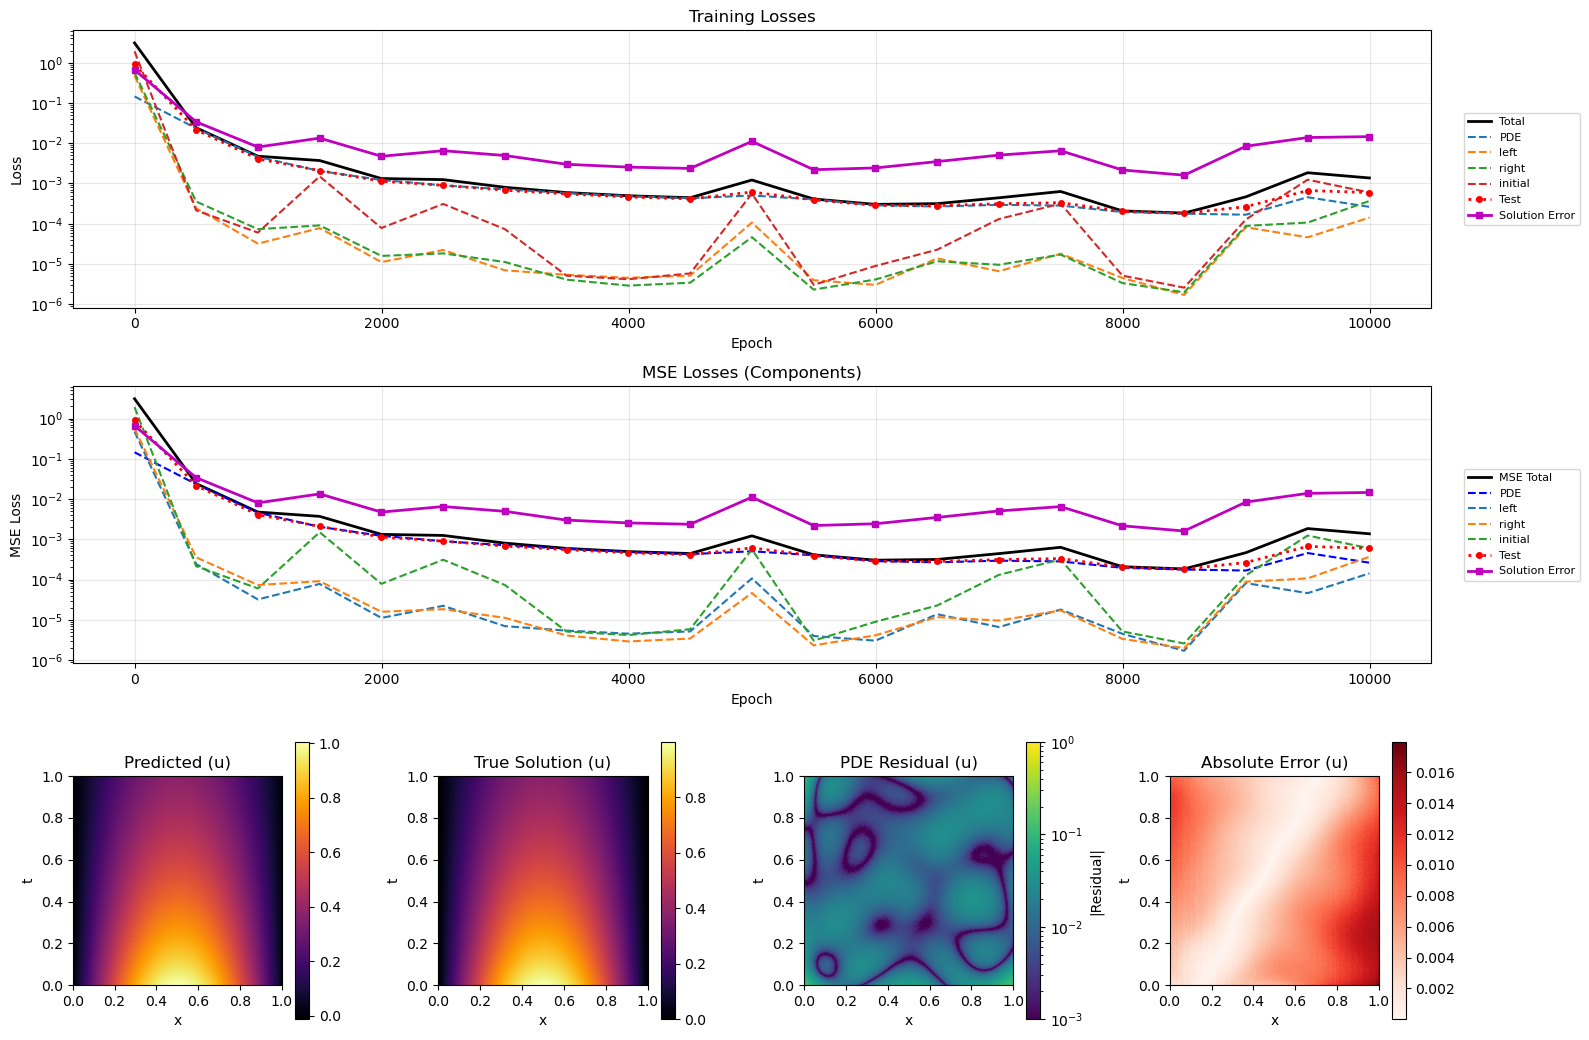

Epoch 0/10000 | Loss: 3.10e+00 | MSE Loss: 3.10e+00 | PDE: 1.45e-01 | BCs: [left: 4.76e-01, right: 5.64e-01, initial: 1.92e+00] | Time: 0.0s | Test Loss: 9.07e-01 | Error: 6.64e-01
Epoch 500/10000 | Loss: 2.42e-02 | MSE Loss: 2.42e-02 | PDE: 2.34e-02 | BCs: [left: 2.42e-04, right: 3.56e-04, initial: 2.14e-04] | Time: 9.3s | Test Loss: 2.15e-02 | Error: 3.39e-02
Epoch 1000/10000 | Loss: 4.75e-03 | MSE Loss: 4.75e-03 | PDE: 4.59e-03 | BCs: [left: 3.20e-05, right: 7.32e-05, initial: 6.02e-05] | Time: 10.2s | Test Loss: 4.08e-03 | Error: 8.03e-03
Epoch 1500/10000 | Loss: 3.71e-03 | MSE Loss: 3.71e-03 | PDE: 2.04e-03 | BCs: [left: 7.78e-05, right: 9.09e-05, initial: 1.50e-03] | Time: 11.1s | Test Loss: 2.09e-03 | Error: 1.34e-02
Epoch 2000/10000 | Loss: 1.33e-03 | MSE Loss: 1.33e-03 | PDE: 1.22e-03 | BCs: [left: 1.11e-05, right: 1.58e-05, initial: 7.82e-05] | Time: 11.9s | Test Loss: 1.14e-03 | Error: 4.74e-03
Epoch 2500/10000 | Loss: 1.25e-03 | MSE Loss: 1.25e-03 | PDE: 8.96e-04 | BCs: [le

In [11]:
trainer.compile(
    train_samples={
        "pde": 5000,      # Interior PDE samples
        "left": 200,      # Left boundary samples
        "right": 200,     # Right boundary samples
        "initial": 500    # Initial condition samples
    },
    test_samples={
        "pde": 500,
        "left": 50,
        "right": 50,
        "initial": 100
    },
    weights={
        "pde": 1.0,
        "left": 10.0,     # Higher weight for BCs
        "right": 10.0,
        "initial": 50.0   # Highest weight for IC
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=500,
    plot_kwargs={
        "residuals": {"norm": LogNorm(vmin=1e-3, vmax=1e0)}
    },
    show_plots=True
)

trainer.train()

## 10. Fine-tune with L-BFGS (Optional)

L-BFGS often provides better convergence for the final refinement phase.

Starting L-BFGS training for 500 epochs (5 iterations per epoch, history=50)...


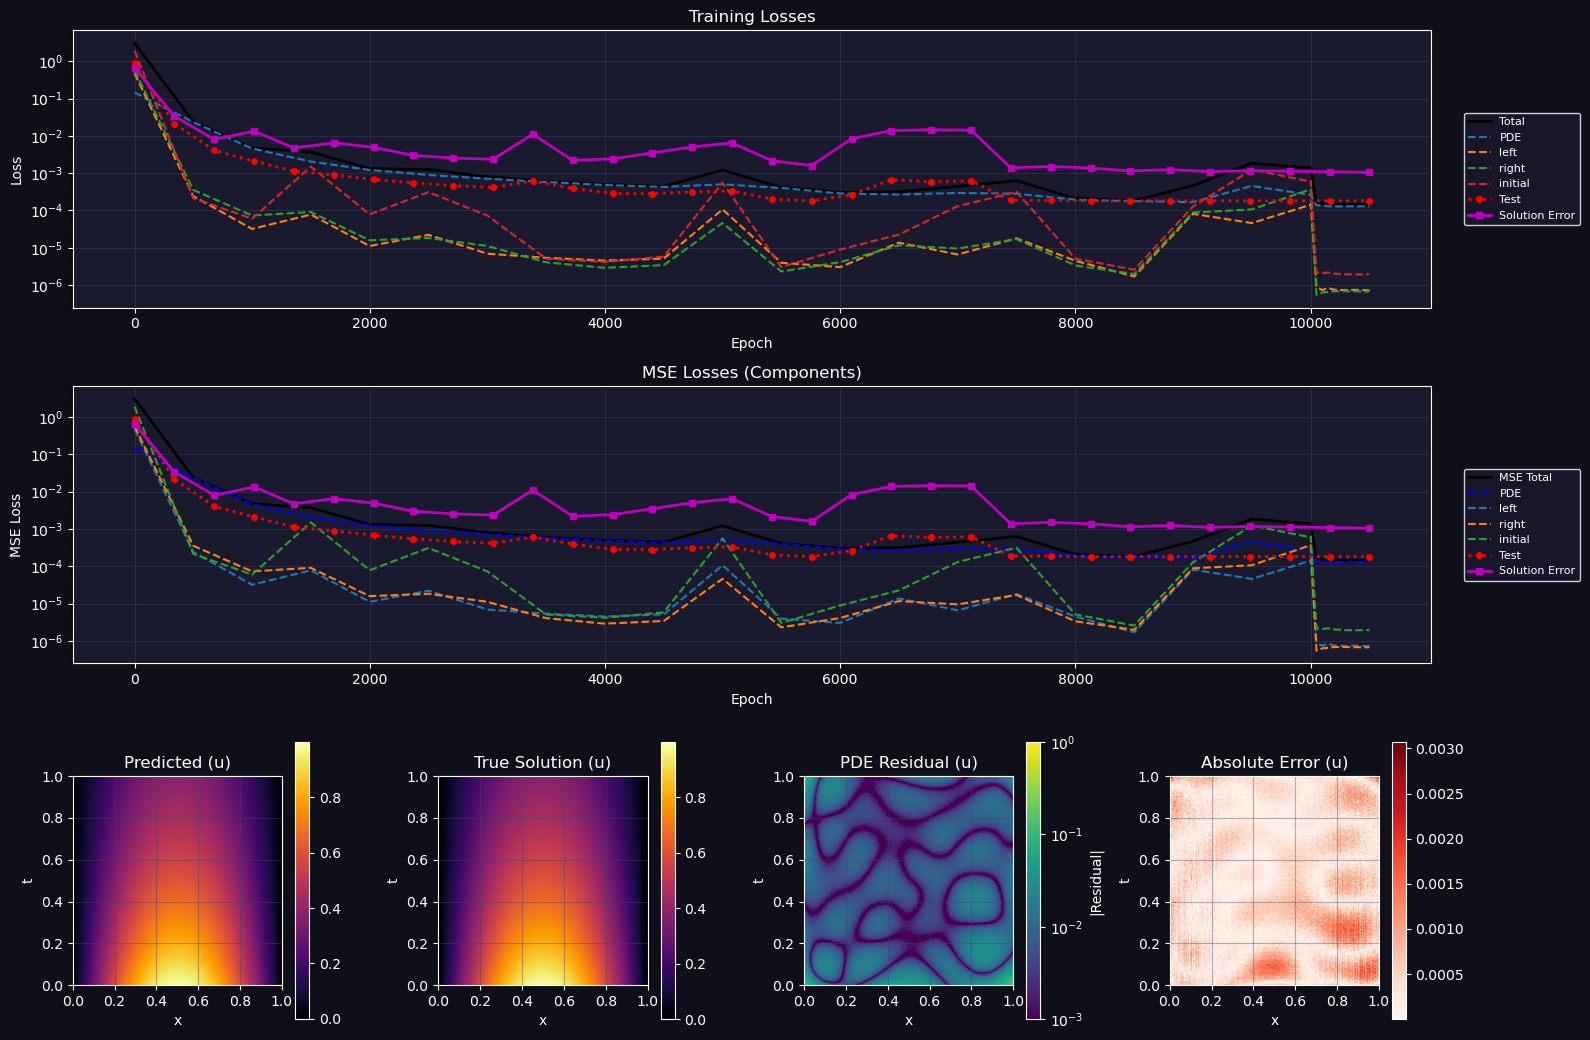

Epoch 0/10500 | Loss: 1.39e-03 | MSE Loss: 1.39e-03 | PDE: 2.60e-04 | BCs: [left: 1.48e-04, right: 3.55e-04, initial: 6.28e-04] | Time: 0.0s | Test Loss: 6.20e-04 | Error: 1.42e-02
Epoch 10050/10500 | Loss: 1.55e-04 | MSE Loss: 1.55e-04 | PDE: 1.37e-04 | BCs: [left: 8.97e-07, right: 5.43e-07, initial: 2.16e-06] | Time: 9.9s | Test Loss: 1.88e-04 | Error: 1.39e-03
Epoch 10100/10500 | Loss: 1.53e-04 | MSE Loss: 1.53e-04 | PDE: 1.36e-04 | BCs: [left: 7.36e-07, right: 6.31e-07, initial: 2.10e-06] | Time: 10.9s | Test Loss: 1.87e-04 | Error: 1.51e-03
Epoch 10150/10500 | Loss: 1.48e-04 | MSE Loss: 1.48e-04 | PDE: 1.30e-04 | BCs: [left: 8.39e-07, right: 6.54e-07, initial: 2.17e-06] | Time: 11.9s | Test Loss: 1.83e-04 | Error: 1.38e-03
Epoch 10200/10500 | Loss: 1.46e-04 | MSE Loss: 1.46e-04 | PDE: 1.29e-04 | BCs: [left: 7.51e-07, right: 6.82e-07, initial: 2.04e-06] | Time: 13.1s | Test Loss: 1.82e-04 | Error: 1.15e-03
Epoch 10250/10500 | Loss: 1.46e-04 | MSE Loss: 1.46e-04 | PDE: 1.29e-04 | BC

In [12]:
trainer.compile(
    optimizer="lbfgs",
    epochs=500,
    print_each=50,
    show_plots=True,
    plot_kwargs={
        "residuals": {"norm": LogNorm(vmin=1e-3, vmax=1e0)}
    },
    plot_style={
        "theme": "dark"
    }
)

trainer.train()